In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow.keras import datasets,layers,models

In [6]:
(X_train,y_train),(X_test,y_test)=datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [22]:
X_train=X_train/255.0
X_test=X_test/255.0

X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

d:\Saran\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
print(model)

<Sequential name=sequential, built=True>


In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
history=model.fit(X_train,y_train,epochs=5,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.9514 - loss: 0.1592 - val_accuracy: 0.9873 - val_loss: 0.0506
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9841 - loss: 0.0516 - val_accuracy: 0.9863 - val_loss: 0.0441
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 91s 53ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9905 - val_loss: 0.0352
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.9913 - loss: 0.0260 - val_accuracy: 0.9890 - val_loss: 0.0400
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9939 - loss: 0.0192 - val_accuracy: 0.9895 - val_loss: 0.0430


In [17]:
test_loss,test_acc=model.evaluate(X_test,y_test)

print('test accuracy : ',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9873 - loss: 0.0380
test accuracy :  0.9872999787330627


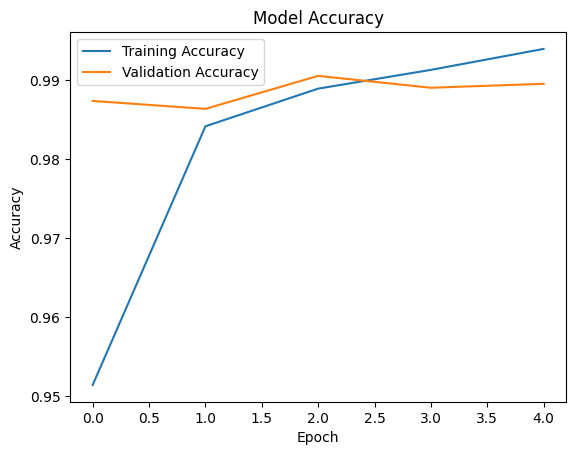

In [18]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [19]:
predictions=model.predict(X_test[:5])
print(" predicted_labels : ",predictions.argmax(axis=1))
print("Actual labels : ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
 predicted_labels :  [7 2 1 0 4]
Actual labels :  [7 2 1 0 4]


CNN for Custom Images

In [215]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers,models


In [216]:
from PIL import Image
import os

dataset_path = r'D:\Saran\cat&dog dataset\PetImages'

deleted = 0

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):

        file_path = os.path.join(folder_path, file)

        try:
            img = Image.open(file_path)
            img.verify()  # verify image integrity
        except:
            print("Deleting corrupted file:", file_path)
            os.remove(file_path)
            deleted += 1

print("Total deleted:", deleted)

Deleting corrupted file: D:\Saran\cat&dog dataset\PetImages\Cat\666.jpg
Deleting corrupted file: D:\Saran\cat&dog dataset\PetImages\Dog\11702.jpg
Total deleted: 2


In [217]:
train=r'D:\Saran\cat&dog dataset\PetImages'
test=r'D:\Saran\cat&dog dataset\PetImages'

In [218]:
# train_data_generate=ImageDataGenerator(
#     rescale=1/255,
#     rotation_range=20,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     validation_split=0.2
# )
train_gen=train_data_generate.flow_from_directory(
    train,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 20000 images belonging to 2 classes.


In [210]:
train_gen=train_data_generate.flow_from_directory(
    train,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

print(train_gen.class_indices)

Found 20000 images belonging to 2 classes.
{'Cat': 0, 'Dog': 1}


In [219]:
validation_gen=train_data_generate.flow_from_directory(
    train,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4998 images belonging to 2 classes.


In [220]:

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(1,activation='sigmoid')

])

# model = models.Sequential([

#     layers.Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)),
#     layers.MaxPooling2D(2,2),

#     layers.Conv2D(32,(3,3),activation='relu'),
#     layers.MaxPooling2D(2,2),

#     layers.Flatten(),

#     layers.Dense(32,activation='relu'),

#     layers.Dense(1,activation='sigmoid')
# ])

In [221]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [223]:
history = model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=5
)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1028s 2s/step - accuracy: 0.8253 - loss: 0.3904 - val_accuracy: 0.8187 - val_loss: 0.3959
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - accuracy: 0.8371 - loss: 0.3669 - val_accuracy: 0.8351 - val_loss: 0.3662
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.8468 - loss: 0.3455 - val_accuracy: 0.8309 - val_loss: 0.3753
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1158s 2s/step - accuracy: 0.8572 - loss: 0.3226 - val_accuracy: 0.8539 - val_loss: 0.3297
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1115s 2s/step - accuracy: 0.8663 - loss: 0.3093 - val_accuracy: 0.8615 - val_loss: 0.3204


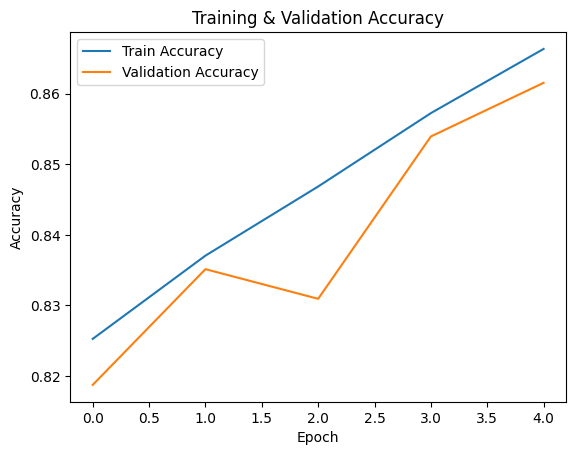

In [224]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [242]:

img_path = r'D:\Saran\cat&dog dataset\test_cat\cat_test.jpg'

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)

img_array = tf.expand_dims(img_array, 0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

prob = prediction[0][0]

print("Raw prediction:", prob)

if prob > 0.5:
    print("Predicted Class: Dog")
else:
    print("Predicted Class: Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Raw prediction: 0.0028649527
Predicted Class: Cat
